# Nebular Emission

Nebular emission (recombination lines + free-free/bound-free continuum)
contributes significantly to galaxy photometry, especially at high
redshift where strong emission lines fall into broadband filters.

tengri provides three nebular backends:

1. **BakedIn**: SSP templates with nebular emission pre-computed at
   fixed ionization parameter and gas metallicity. Zero extra parameters.
2. **CloudyGrid**: Pre-computed CLOUDY photoionization grids with free
   $\log U$ and gas metallicity. Lines + continuum via interpolation.
3. **Cue**: Neural net emulator (Li et al. 2025) with 12 free parameters
   including abundance ratios. Pure JAX, JIT-compatible.

In [1]:
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fixed,
    Model,
    ParamSpec,
    load_ssp_data,
)
from tengri.models.nebular import BakedInBackend

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

from _plot_style import COLORS, SPECTRAL_FEATURES, setup_style

setup_style()

FIGDIR = os.path.join(_nb_dir, "..", "figures", "reference")
os.makedirs(FIGDIR, exist_ok=True)

## 1. BakedIn Backend: Default Nebular Emission

The default SSP files (`wNE` = with Nebular Emission) include nebular
emission pre-computed at fixed $\log U = -3.0$ and solar gas metallicity.
This is the simplest option: no extra free parameters.

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

# SED with baked-in nebular emission (default)
spec = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Fixed(1.5),
    sfh_tsnorm_peak_lbt_gyr=Fixed(0.5),
    sfh_tsnorm_width_gyr=Fixed(0.5),
    sfh_tsnorm_skew=Fixed(0.0),
    sfh_tsnorm_trunc=Fixed(5.0),
    met_logzsol=Fixed(-0.3),
    dust_tau_bc=Fixed(0.0),
    dust_tau_diff=Fixed(0.0),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.0),
)
model = Model(spec, ssp_data)
params = {
    "sfh_tsnorm_log_peak_sfr": 1.5,
    "sfh_tsnorm_peak_lbt_gyr": 0.5,
    "sfh_tsnorm_width_gyr": 0.5,
    "sfh_tsnorm_skew": 0.0,
    "sfh_tsnorm_trunc": 5.0,
    "met_logzsol": -0.3,
    "dust_tau_bc": 0.0,
    "dust_tau_diff": 0.0,
    "dust_slope": -0.7,
    "redshift": 0.0,
}
sed_with_neb = model.predict_sed(params)
wave = ssp_data.ssp_wave

W0329 14:59:03.946591 26291054 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 2. Key Emission Lines

Strong emission lines visible in the SED: Ly-alpha, H-beta, [O III],
H-alpha. These lines encode information about ionizing flux, gas
metallicity, and dust.

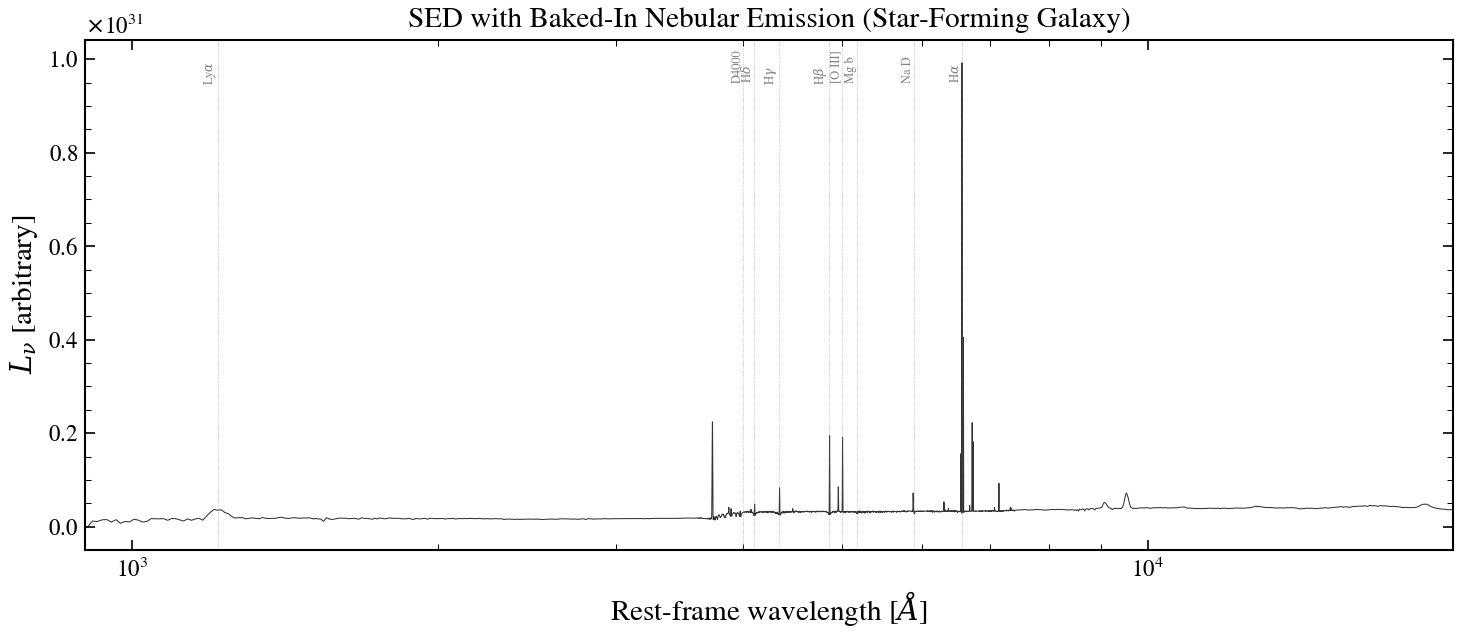

In [3]:
# --- FIGURE 1: Full SED with emission line labels ---
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(np.array(wave), np.array(sed_with_neb), "k-", lw=0.5, alpha=0.8)

# Mark spectral features
for name, wave_line in SPECTRAL_FEATURES.items():
    if 900 < wave_line < 10000:
        ax.axvline(wave_line, ls=":", color="grey", lw=0.4, alpha=0.6)
        ax.annotate(
            name,
            xy=(wave_line, 0.92),
            xycoords=("data", "axes fraction"),
            fontsize=6,
            rotation=90,
            ha="right",
            color="grey",
        )

ax.set_xlabel(r"Rest-frame wavelength [$\AA$]")
ax.set_ylabel(r"$L_\nu$ [arbitrary]")
ax.set_title("SED with Baked-In Nebular Emission (Star-Forming Galaxy)")
ax.set_xscale("log")
ax.set_xlim(900, 20000)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "05_sed_nebular.png"), bbox_inches="tight")
plt.show()

## 3. Emission Line Zoom: Optical Region

The optical window contains the strongest diagnostic lines for SED
fitting: H-beta (4861 A), [O III] doublet (4959, 5007 A), H-alpha
(6563 A), and [N II] (6548, 6583 A).

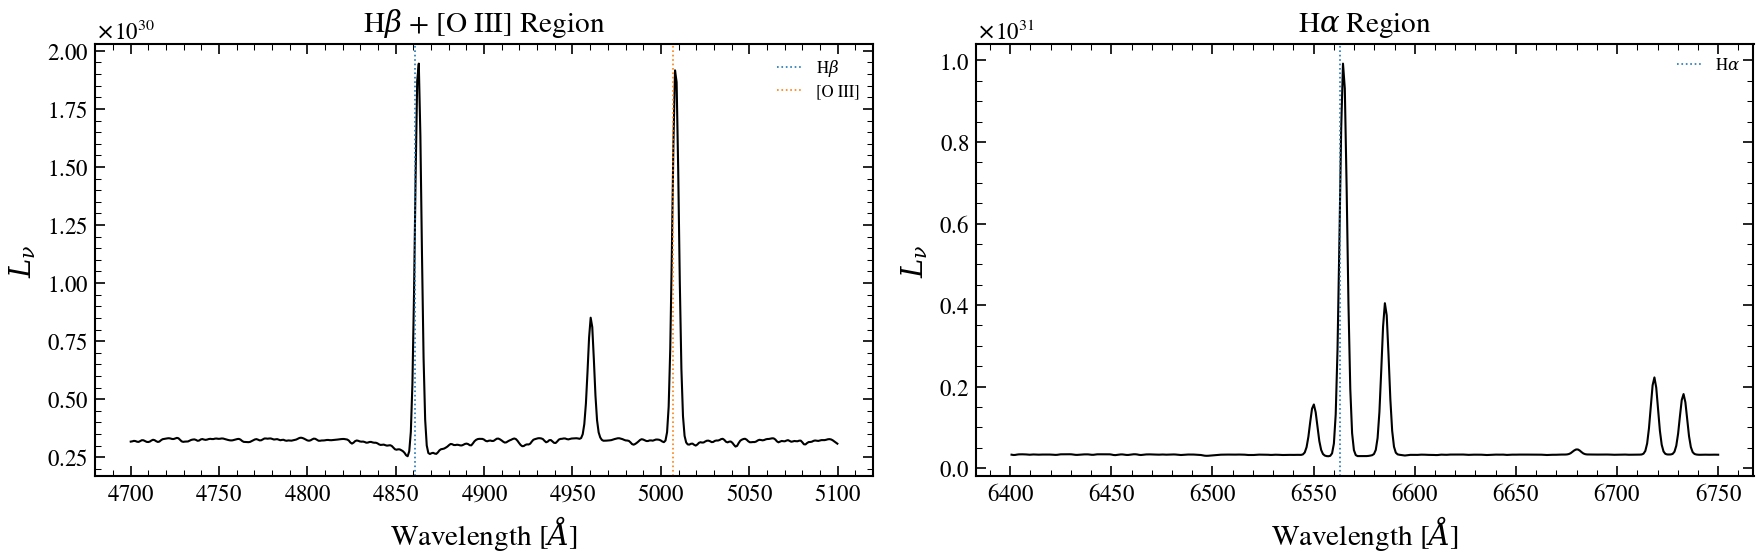

In [4]:
# --- FIGURE 2: Optical emission line zoom ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: H-beta + [O III] region
ax = axes[0]
mask = (wave > 4700) & (wave < 5100)
ax.plot(np.array(wave[mask]), np.array(sed_with_neb[mask]), "k-", lw=1.0)
ax.axvline(4861, ls=":", color=COLORS["rt"], lw=0.8, label=r"H$\beta$")
ax.axvline(5007, ls=":", color=COLORS["geovi"], lw=0.8, label="[O III]")
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"$L_\nu$")
ax.set_title(r"H$\beta$ + [O III] Region")
ax.legend(fontsize=8, frameon=False)

# Right: H-alpha region
ax = axes[1]
mask = (wave > 6400) & (wave < 6750)
ax.plot(np.array(wave[mask]), np.array(sed_with_neb[mask]), "k-", lw=1.0)
ax.axvline(6563, ls=":", color=COLORS["rt"], lw=0.8, label=r"H$\alpha$")
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"$L_\nu$")
ax.set_title(r"H$\alpha$ Region")
ax.legend(fontsize=8, frameon=False)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "05_emission_line_zoom.png"), bbox_inches="tight")
plt.show()

## 4. Backend Comparison Table

| Backend | Free params | Speed | Flexibility | Data needed |
|---------|------------|-------|-------------|-------------|
| BakedIn | 0 | Fastest | None (fixed logU, Z) | SSP `wNE` file |
| CloudyGrid | 2 (logU, Z_gas) | Fast | Moderate | CLOUDY HDF5 grid |
| Cue | 12 | Moderate | Full (abundances) | Neural net weights |

For most photometric fitting, BakedIn is sufficient. CloudyGrid adds
ionization parameter freedom for spectroscopic fitting. Cue provides
the most flexibility for detailed abundance studies.

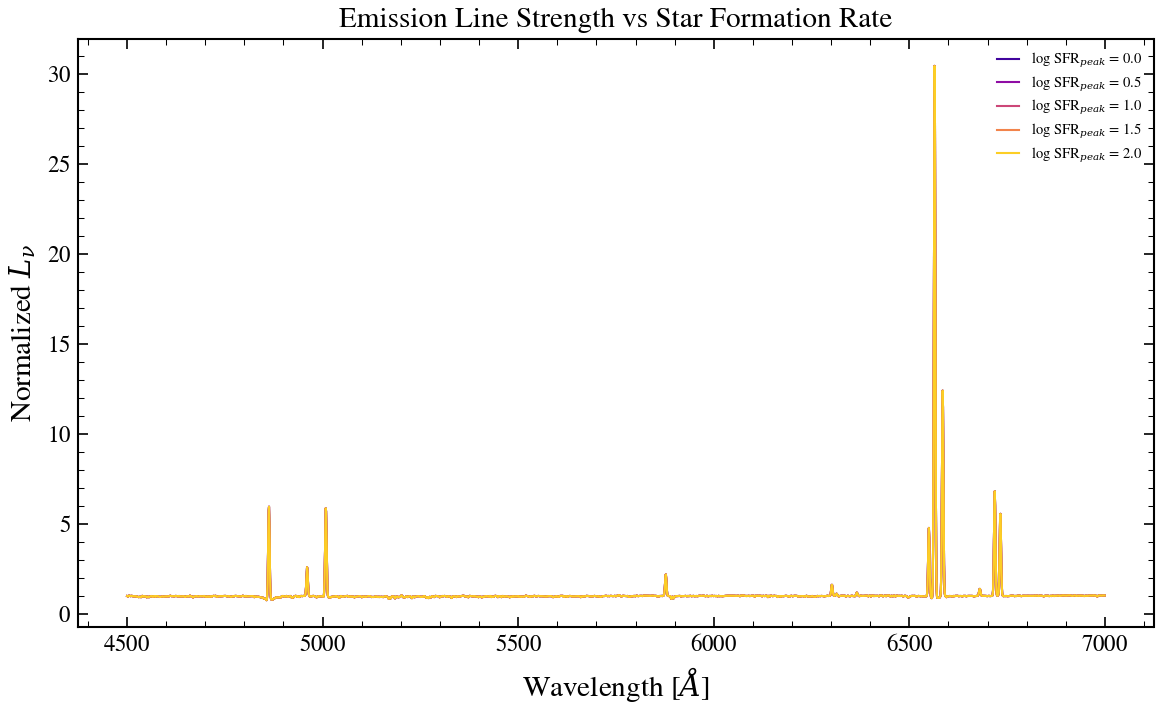

In [5]:
# --- FIGURE 3: SFR dependence of emission lines ---
# Show how the emission line EW changes with SFR (using different peak SFRs)
fig, ax = plt.subplots(figsize=(8, 5))

log_peak_sfrs = [0.0, 0.5, 1.0, 1.5, 2.0]
sfr_colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(log_peak_sfrs)))

for log_sfr, color in zip(log_peak_sfrs, sfr_colors):
    params_var = dict(params)
    params_var["sfh_tsnorm_log_peak_sfr"] = log_sfr
    sed_var = model.predict_sed(params_var)
    # Normalize at 5500 A
    idx_norm = int(jnp.argmin(jnp.abs(wave - 5500.0)))
    sed_norm = sed_var / sed_var[idx_norm]
    mask = (wave > 4500) & (wave < 7000)
    ax.plot(
        np.array(wave[mask]),
        np.array(sed_norm[mask]),
        color=color,
        lw=1.0,
        label=f"log SFR$_{{peak}}$ = {log_sfr}",
    )

ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"Normalized $L_\nu$")
ax.set_title("Emission Line Strength vs Star Formation Rate")
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "05_eline_vs_sfr.png"), bbox_inches="tight")
plt.show()

## 5. Shock Emission Lines (MAPPINGS V)

Radiative shocks from supernovae, AGN outflows, and mergers produce emission
spectra that are distinct from HII regions. The key signatures are enhanced
low-ionization lines ([NII], [SII], [OI]) at low/moderate shock velocities,
and strong [OIII] at intermediate velocities (~300-400 km/s).

tengri includes a MAPPINGS V shock model (Allen+2008) that interpolates
tabulated line ratios as a function of shock velocity (100-1000 km/s).

In [6]:
from tengri.models.nebular import shock_line_ratios, shock_emission_sed

# Compute shock line ratios across a velocity grid
velocities = np.linspace(100.0, 1000.0, 200)
ratios_nii_ha = []
ratios_sii_ha = []
ratios_oi_ha = []
ratios_oiii_hb = []

for v in velocities:
    r = shock_line_ratios(float(v))
    ha = float(r["Halpha"])
    ratios_nii_ha.append(float(r["NII_6583"]) / ha)
    ratios_sii_ha.append(float(r["SII_6716"] + r["SII_6731"]) / ha)
    ratios_oi_ha.append(float(r["OI_6300"]) / ha)
    ratios_oiii_hb.append(float(r["OIII_5007"]))  # already relative to Hbeta

ratios_nii_ha = np.array(ratios_nii_ha)
ratios_sii_ha = np.array(ratios_sii_ha)
ratios_oi_ha = np.array(ratios_oi_ha)
ratios_oiii_hb = np.array(ratios_oiii_hb)

### Shock diagnostic line ratios vs velocity

At low velocities ($v_s \lesssim 200$ km/s), shocks enhance [NII]/H$\alpha$
and [SII]/H$\alpha$ well above typical HII region values (dashed lines).
[OIII]/H$\beta$ peaks at $v_s \approx 400$ km/s. These diagnostics place
shocks in distinct regions of BPT diagrams.

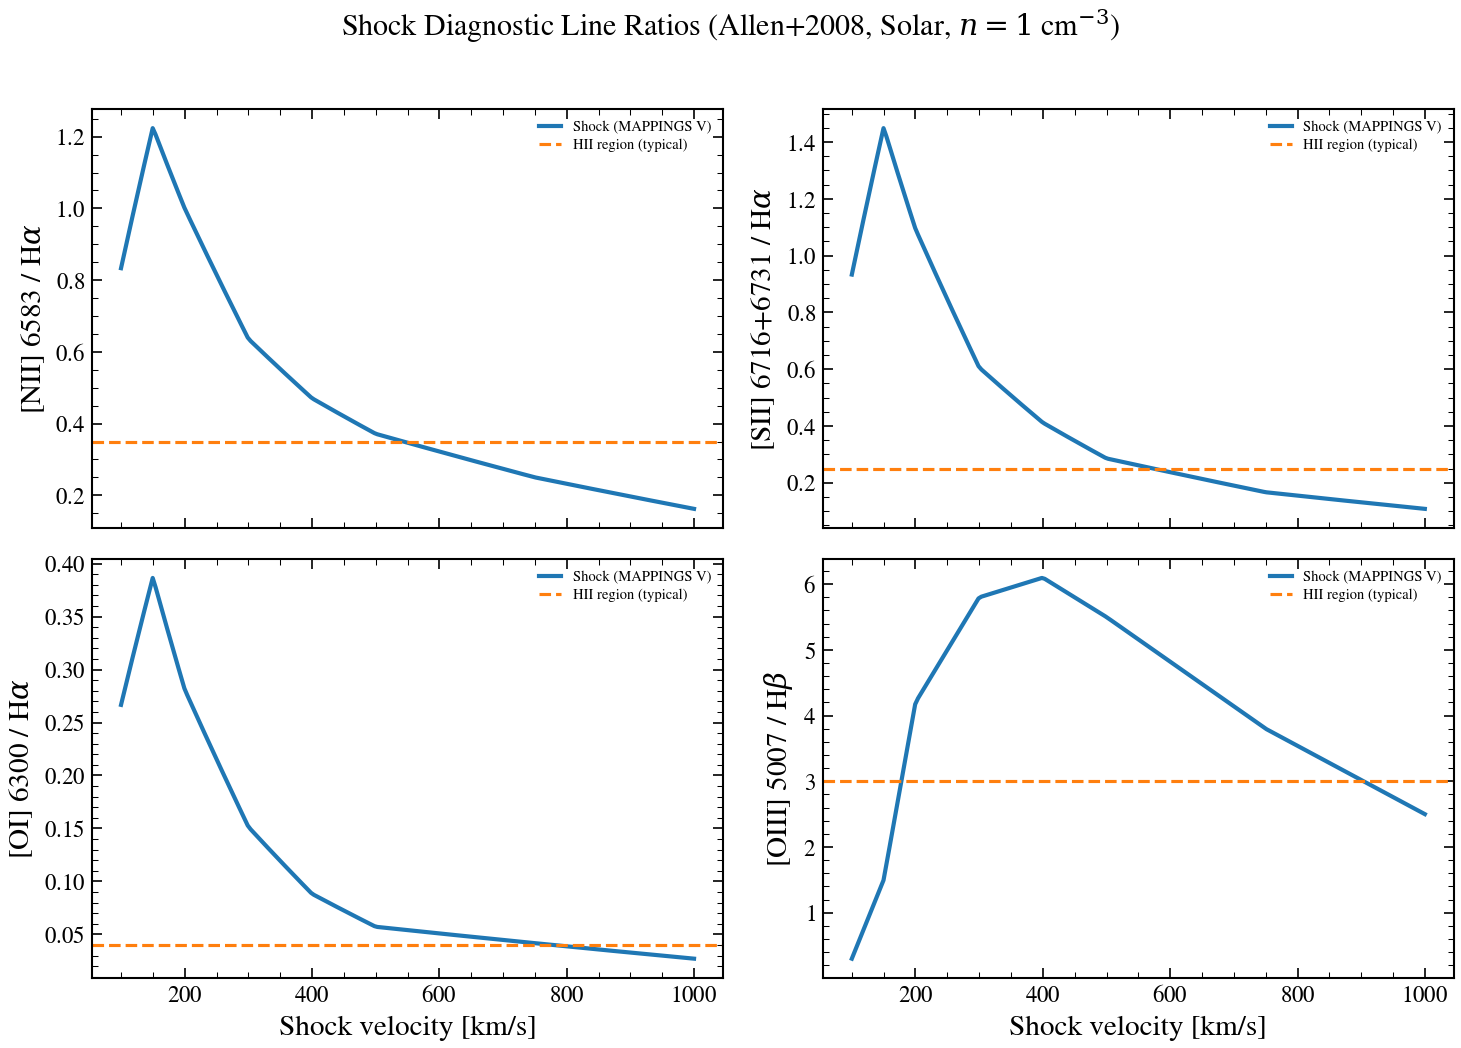

In [7]:
# --- FIGURE: Shock line ratios vs velocity ---
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

# Typical HII region values for comparison (Kewley+2006)
hii_nii_ha = 0.35
hii_sii_ha = 0.25
hii_oi_ha = 0.04
hii_oiii_hb = 3.0

panels = [
    (axes[0, 0], ratios_nii_ha, "[NII] 6583 / H$\\alpha$", hii_nii_ha),
    (axes[0, 1], ratios_sii_ha, "[SII] 6716+6731 / H$\\alpha$", hii_sii_ha),
    (axes[1, 0], ratios_oi_ha, "[OI] 6300 / H$\\alpha$", hii_oi_ha),
    (axes[1, 1], ratios_oiii_hb, "[OIII] 5007 / H$\\beta$", hii_oiii_hb),
]

for ax, ratio, ylabel, hii_val in panels:
    ax.plot(velocities, ratio, color=COLORS["rt"], lw=2.0, label="Shock (MAPPINGS V)")
    ax.axhline(hii_val, color=COLORS["geovi"], ls="--", lw=1.5, label="HII region (typical)")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, frameon=False)

axes[1, 0].set_xlabel("Shock velocity [km/s]")
axes[1, 1].set_xlabel("Shock velocity [km/s]")
fig.suptitle("Shock Diagnostic Line Ratios (Allen+2008, Solar, $n=1$ cm$^{-3}$)", y=1.01)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "05_shock_line_ratios.png"), bbox_inches="tight")
plt.show()

## 6. Shock-HII Mixing

In real galaxies, the observed emission is a composite of HII regions and
shock-heated gas. The shock fraction $f_{\rm shock}$ controls the relative
contribution. At $f_{\rm shock} = 0$ the spectrum is pure HII (baked-in
nebular); at $f_{\rm shock} = 1$ the spectrum is pure shock emission.

The composite SED is:

$$L_{\rm total}(\lambda) = (1 - f_{\rm shock}) \, L_{\rm HII}(\lambda) + f_{\rm shock} \, L_{\rm shock}(\lambda)$$

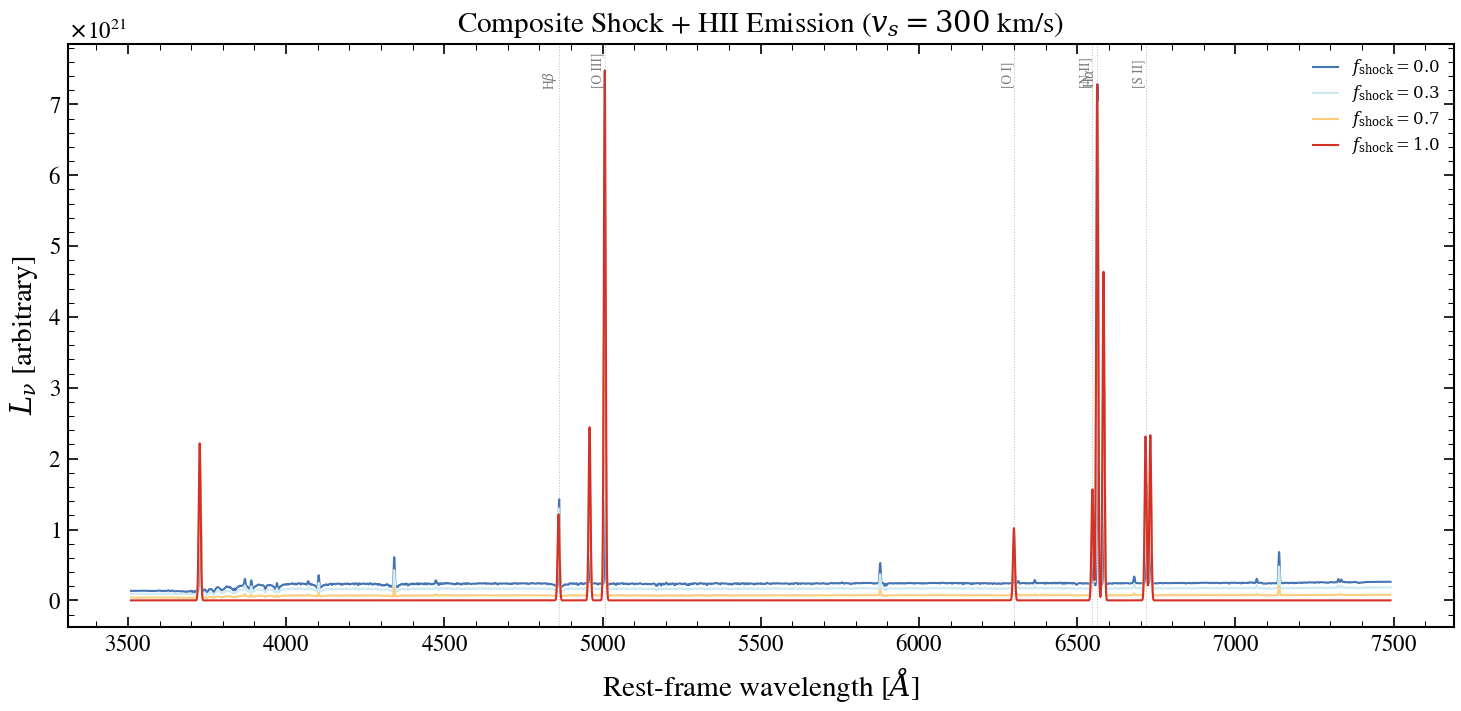

In [8]:
# Build a shock SED on the SSP wavelength grid for a 300 km/s shock
wave_grid = np.array(wave)
shock_fracs = [0.0, 0.3, 0.7, 1.0]
shock_v = 300.0
l_halpha_ref = 1e8  # arbitrary reference Halpha luminosity [Lsun]

shock_sed = np.array(
    shock_emission_sed(jnp.array(wave_grid), shock_v, l_halpha_ref, line_sigma_aa=3.0)
)

# Normalize the HII SED so its Halpha region matches the shock reference
ha_mask = (wave_grid > 6540) & (wave_grid < 6590)
hii_sed = np.array(sed_with_neb)
hii_scale = shock_sed[ha_mask].max() / np.maximum(hii_sed[ha_mask].max(), 1e-30)
hii_sed_scaled = hii_sed * hii_scale

# --- FIGURE: Composite shock + HII SEDs ---
fig, ax = plt.subplots(figsize=(10, 5))
shock_colors = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, len(shock_fracs)))

for frac, color in zip(shock_fracs, shock_colors):
    composite = (1.0 - frac) * hii_sed_scaled + frac * shock_sed
    mask = (wave_grid > 3500) & (wave_grid < 7500)
    ax.plot(
        wave_grid[mask],
        composite[mask],
        color=color,
        lw=1.0,
        label=f"$f_{{\\rm shock}} = {frac}$",
    )

# Label key diagnostic lines
diag_lines = {
    r"H$\beta$": 4861.0,
    "[O III]": 5007.0,
    "[O I]": 6300.0,
    "[N II]": 6548.0,
    r"H$\alpha$": 6563.0,
    "[S II]": 6716.0,
}
for name, lw_line in diag_lines.items():
    ax.axvline(lw_line, ls=":", color="grey", lw=0.5, alpha=0.5)
    ax.annotate(
        name,
        xy=(lw_line, 0.93),
        xycoords=("data", "axes fraction"),
        fontsize=6.5,
        rotation=90,
        ha="right",
        color="grey",
    )

ax.set_xlabel(r"Rest-frame wavelength [$\AA$]")
ax.set_ylabel(r"$L_\nu$ [arbitrary]")
ax.set_title(f"Composite Shock + HII Emission ($v_s = {shock_v:.0f}$ km/s)")
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "05_shock_hii_mixing.png"), bbox_inches="tight")
plt.show()

## 7. Diffuse Ionized Gas (DIG) Mixing

The diffuse ionized gas (DIG) permeating galaxies has a lower ionization
parameter ($\log U \sim -4$) than HII regions ($\log U \sim -2.5$ to $-3$).
This enhances low-ionization lines ([NII]/H$\alpha$, [SII]/H$\alpha$).
Typical DIG fractions are 30-60% of total H$\alpha$ in local galaxies
(Reynolds 1984; Haffner+2009; Tacchella+2022).

The DIG mixing model evaluates any nebular backend at two ionization
parameters:

$$L_{\rm total} = (1 - f_{\rm DIG}) \, L(\log U_{\rm HII}) + f_{\rm DIG} \, L(\log U_{\rm DIG})$$

where $\log U_{\rm DIG} = \log U_{\rm HII} + \Delta\log U$ (with
$\Delta\log U \approx -1$ dex).

In [9]:
from tengri.models.nebular import mix_dig_emission

### Concept: DIG effect on line ratios

Since DIG mixing requires a backend with a ``predict_nebular_sed`` method
that accepts ``neb_logU``, we demonstrate the concept using a mock
backend that returns synthetic spectra at different ionization parameters.
The key physics: lower $\log U$ shifts the ionization balance toward
low-ionization species, enhancing [NII], [SII], [OI] relative to H$\alpha$.

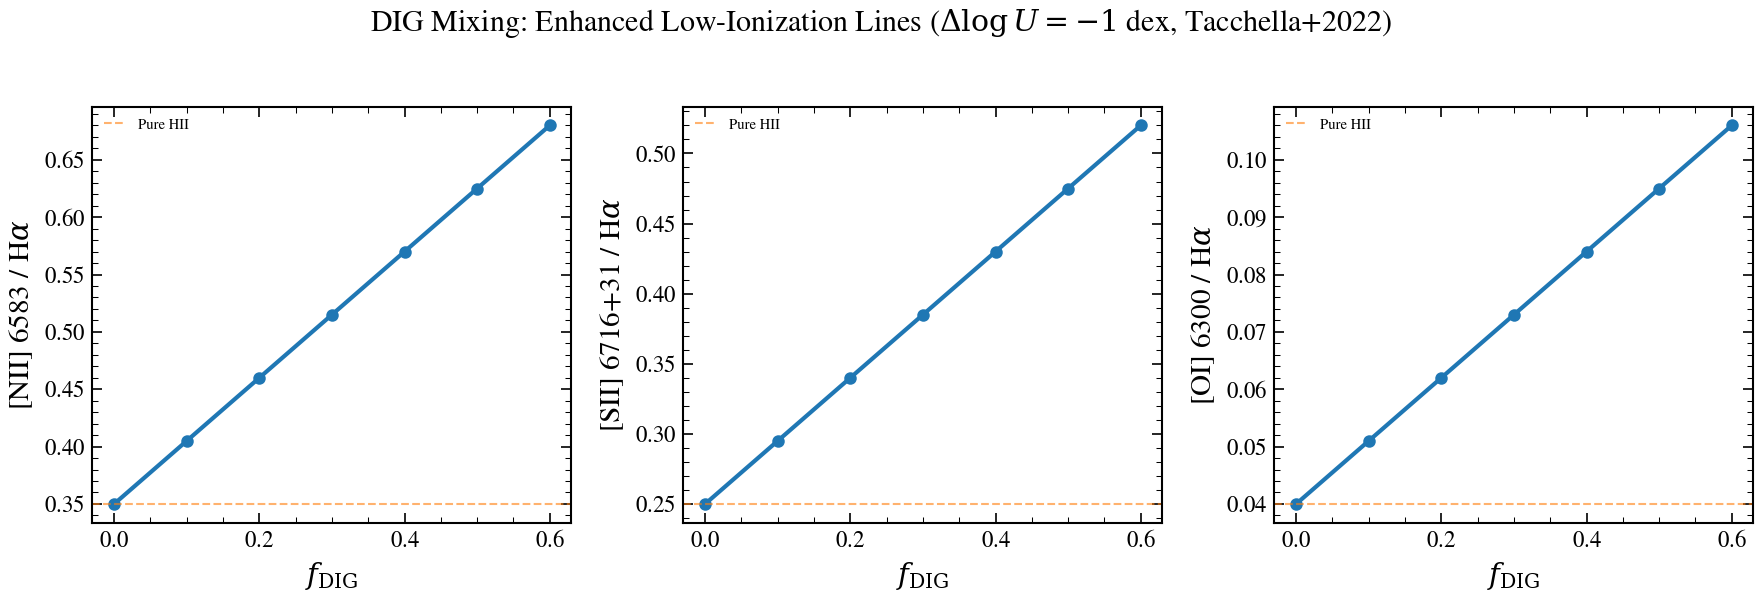

In [10]:
# Mock DIG demonstration: show the conceptual effect of DIG fraction
# on diagnostic line ratios using the Allen+2008 shock model as a proxy
# for the low-ionization DIG spectrum (both share enhanced low-ion lines).
#
# In a full setup, mix_dig_emission() would be called with a CloudyGrid
# or Cue backend. Here we illustrate the expected trend.

dig_fracs = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])

# HII region ratios (typical logU = -3)
hii_nii_ha_ref = 0.35
hii_sii_ha_ref = 0.25
hii_oi_ha_ref = 0.04

# DIG ratios (typical logU = -4, enhanced low-ionization)
# Based on Tacchella+2022 Fig 3; DIG has ~2-3x higher [NII]/Ha, [SII]/Ha
dig_nii_ha_ref = 0.90
dig_sii_ha_ref = 0.70
dig_oi_ha_ref = 0.15

# Linear mixing of line ratios with DIG fraction
mixed_nii = (1 - dig_fracs) * hii_nii_ha_ref + dig_fracs * dig_nii_ha_ref
mixed_sii = (1 - dig_fracs) * hii_sii_ha_ref + dig_fracs * dig_sii_ha_ref
mixed_oi = (1 - dig_fracs) * hii_oi_ha_ref + dig_fracs * dig_oi_ha_ref

# --- FIGURE: DIG effect on line ratios ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)

panels_dig = [
    (axes[0], mixed_nii, "[NII] 6583 / H$\\alpha$"),
    (axes[1], mixed_sii, "[SII] 6716+31 / H$\\alpha$"),
    (axes[2], mixed_oi, "[OI] 6300 / H$\\alpha$"),
]

for ax, ratio, ylabel in panels_dig:
    ax.plot(dig_fracs, ratio, "o-", color=COLORS["rt"], lw=2.0, ms=5)
    ax.axhline(ratio[0], ls="--", color=COLORS["geovi"], lw=1.0, alpha=0.6, label="Pure HII")
    ax.set_xlabel("$f_{\\rm DIG}$")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, frameon=False)

fig.suptitle(
    "DIG Mixing: Enhanced Low-Ionization Lines ($\\Delta\\log U = -1$ dex, Tacchella+2022)",
    y=1.02,
)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "05_dig_mixing.png"), bbox_inches="tight")
plt.show()

### DIG mixing API

In production, DIG mixing is handled by ``mix_dig_emission()`` which wraps
any nebular backend:

```python
from tengri.models.nebular import mix_dig_emission, CloudyGridBackend

backend = CloudyGridBackend("data/cloudy_grid.h5", ssp_data)
neb_sed = mix_dig_emission(
    backend, ssp_wave, ssp_weights, ssp_log_ages_yr, log_z,
    neb_logU=-3.0,
    neb_dig_frac=0.4,       # 40% DIG contribution
    neb_dig_delta_logU=-1.0, # DIG at logU = -4
)
```

The function evaluates the backend twice (at $\log U_{\rm HII}$ and
$\log U_{\rm DIG}$) and returns the weighted sum. When ``neb_dig_frac=0``
(default), it returns pure HII emission with zero overhead.

## Summary

Nebular emission is critical for accurate SED fitting, especially for:
- Young, star-forming galaxies with strong emission lines
- High-redshift galaxies where lines fall in photometric bands
- Spectroscopic fitting where line shapes carry physical information

Beyond standard HII region emission, tengri also supports:
- **Shock emission** (MAPPINGS V): distinct line ratios at different
  shock velocities, composable with HII via a mixing fraction
- **DIG mixing**: diffuse ionized gas with lower ionization parameter,
  enhancing [NII], [SII], [OI] relative to pure HII regions

The BakedIn backend requires no extra data files and is the recommended
starting point. Switch to CloudyGrid or Cue when you need to fit
ionization parameter or detailed abundances.

**See also:** [Nebular Backends Deep-Dive](../_notebooks/reference/12_nebular_backends) for
detailed CloudyGrid grid inspection, Cue emulator architecture, and backend comparison.